Costruisco libreria bilanciata...
Campiono dataset per PINN...
Costruisco validation set bilanciato (Monte Carlo)...
Calcolo prezzi Monte Carlo bilanciati...
Inizio training PINN...
[   1] total=1.257001  PDE=0.000867  term=0.048138  bnd=1.159857
[ 200] total=0.035016  PDE=0.001577  term=0.009937  bnd=0.013565
[ 400] total=0.008129  PDE=0.000856  term=0.001391  bnd=0.004491
[ 600] total=0.004499  PDE=0.000734  term=0.000925  bnd=0.001916
[ 800] total=0.003534  PDE=0.000382  term=0.001036  bnd=0.001080
[1000] total=0.002999  PDE=0.000516  term=0.000782  bnd=0.000919
[1200] total=0.003379  PDE=0.000415  term=0.001006  bnd=0.000953
[1400] total=0.002299  PDE=0.000320  term=0.000719  bnd=0.000541
[1600] total=0.002078  PDE=0.000354  term=0.000590  bnd=0.000544
[1800] total=0.002333  PDE=0.000260  term=0.000833  bnd=0.000407
[2000] total=0.002158  PDE=0.000267  term=0.000732  bnd=0.000427
[2200] total=0.001828  PDE=0.000215  term=0.000635  bnd=0.000343
[2400] total=0.001813  PDE=0.000293  t

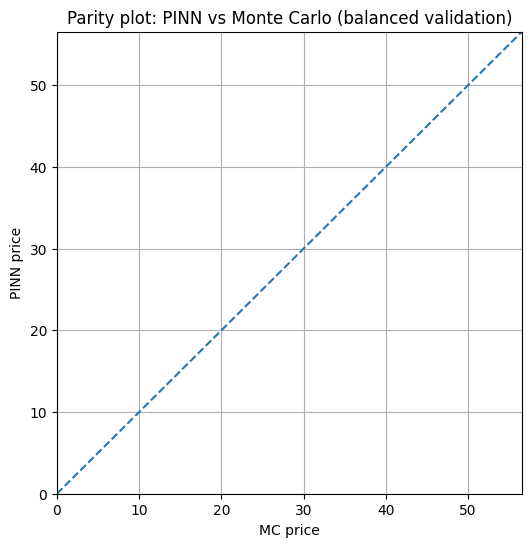

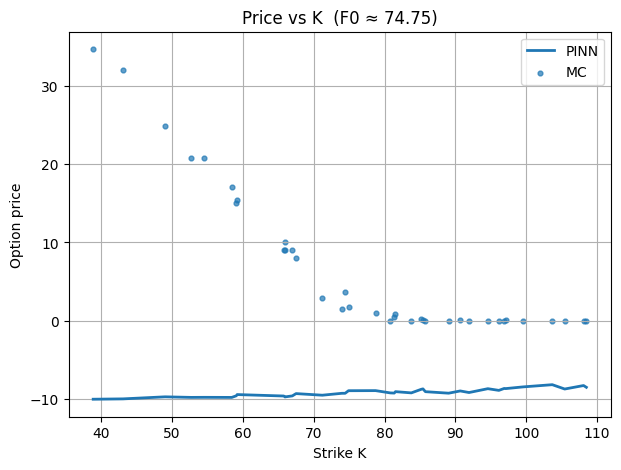


Metriche finali: {'MAE': 19.657123565673828, 'RMSE': 24.424531505390487, 'R2': -2.4115757942199707}


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PINN per Asian option (average price) su future WTI.
Versione con dataset bilanciato e parity plot PINN vs Monte Carlo.
"""

import os
import math
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from utils import make_business_calendar
from utils import simulate_future_gbm
from utils import arithmetic_average
from utils import build_library_balanced

from utils_models import normalize_df
from utils_models import pack_inputs

from datasets import sample_collocation_balanced
from datasets import sample_terminal_balanced
from datasets import sample_boundary_balanced
from datasets import price_asian_arith_mc
from datasets import build_validation_mc_balanced

from model1_MLP import MLP
from model1_MLP import pde_residual
from model1_MLP import minibatch

from evaluation import evaluate_pinn_vs_mc

# PARAMETERS

np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "./dataset_asian_wti_balanced"
os.makedirs(OUT_DIR, exist_ok=True)

RISK_FREE = 0.02      
AVG_BUSINESS_DAYS = 20

# dataset
N_LIBRARY        = 3000
N_COLLOCATION    = 200_000
N_TERMINAL       = 25_000
N_BOUNDARY       = 20_000
N_VALIDATION_MC  = 1_000

F0_RANGE         = (40.0, 110.0)
MONEY_RANGE      = (0.5, 1.5)     # K/F0
SIGMA_RANGE      = (0.15, 0.60)
R_RANGE          = (0.00, 0.05)



# 6) MODELLO PINN (MLP)

HIDDEN = 256
LAYERS = 5
LR = 1e-3
EPOCHS = 3000
BATCH_C = 2048
BATCH_T = 512
BATCH_B = 512
ALPHA, BETA, GAMMA = 1.0, 2.0, 1.0
GRAD_CLIP = 1.0


# ============================================================
# 7) COSTRUZIONE DATASET + TRAINING PINN
# ============================================================
print("Costruisco libreria bilanciata...")
df_lib = build_library_balanced()

print("Campiono dataset per PINN...")
df_coll = sample_collocation_balanced(df_lib, n=N_COLLOCATION)
df_term = sample_terminal_balanced(df_lib, n=N_TERMINAL)
df_bdry = sample_boundary_balanced(df_lib, n=N_BOUNDARY)

print("Costruisco validation set bilanciato (Monte Carlo)...")
df_val = build_validation_mc_balanced(n=N_VALIDATION_MC)

# Normalizzazione
dfc = normalize_df(df_coll)
dft = normalize_df(df_term)
dfb = normalize_df(df_bdry)

Xc_full = pack_inputs(dfc)
Xt_full = pack_inputs(dft)
Xb_full = pack_inputs(dfb)

yT = torch.tensor((df_term["target_V"].values / df_term["F0_ref"].values),
                  dtype=torch.float32, device=DEVICE).unsqueeze(1)
yB = torch.tensor((df_bdry["target_V"].values / df_bdry["F0_ref"].values),
                  dtype=torch.float32, device=DEVICE).unsqueeze(1)

model = MLP().to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
mse = nn.MSELoss()

print("Inizio training PINN...")
for epoch in range(1, EPOCHS + 1):
    model.train()

    Xc, _ = minibatch(Xc_full, BATCH_C)
    Rc = pde_residual(model, Xc)
    loss_phys = torch.mean(Rc**2)

    Xt, it = minibatch(Xt_full, BATCH_T)
    pred_T = model(Xt)
    loss_term = mse(pred_T, yT[it])

    Xb, ib = minibatch(Xb_full, BATCH_B)
    pred_B = model(Xb)
    loss_bound = mse(pred_B, yB[ib])

    loss = ALPHA * loss_phys + BETA * loss_term + GAMMA * loss_bound

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    opt.step()
    scheduler.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"[{epoch:4d}] total={loss.item():.6f}  "
              f"PDE={loss_phys.item():.6f}  term={loss_term.item():.6f}  bnd={loss_bound.item():.6f}")
        

metrics = evaluate_pinn_vs_mc(df_val, tau=0.999)
print("\nMetriche finali:", metrics)


In [2]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from utils import build_library_balanced
from utils import rnd_series
from utils import make_gid_from_available

from utils_models import normalize_df
from utils_models import pack_inputs

from datasets import sample_collocation_balanced
from datasets import sample_terminal_balanced
from datasets import sample_boundary_balanced
from datasets import build_validation_mc_balanced

from model1_MLP import MLP
from model1_MLP import pde_residual
from model1_MLP import minibatch

from evaluation import evaluate_pinn_vs_mc

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.float_format", "{:,.4f}".format)



# PARAMETERS

np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "./dataset_asian_wti_balanced"
os.makedirs(OUT_DIR, exist_ok=True)

RISK_FREE = 0.02
AVG_BUSINESS_DAYS = 20

# Dataset sizes
N_LIBRARY        = 3000
N_COLLOCATION    = 200_000
N_TERMINAL       = 25_000
N_BOUNDARY       = 20_000
N_VALIDATION_MC  = 1_000

# Parameter ranges
F0_RANGE         = (40.0, 110.0)
MONEY_RANGE      = (0.5, 1.5)     # K / F0
SIGMA_RANGE      = (0.15, 0.60)
R_RANGE          = (0.00, 0.05)

# Model's parameters
HIDDEN = 256
LAYERS = 5
LR = 1e-3
EPOCHS = 3000
BATCH_C = 2048
BATCH_T = 512
BATCH_B = 512
ALPHA, BETA, GAMMA = 1.0, 2.0, 1.0
GRAD_CLIP = 1.0



# DATASET CONSTRUCTION 

print("Building balanced trajectory library...")
df_lib = build_library_balanced()

print("Sampling datasets for PINN training...")
df_coll = sample_collocation_balanced(df_lib, n=N_COLLOCATION)
df_term = sample_terminal_balanced(df_lib, n=N_TERMINAL)
df_bdry = sample_boundary_balanced(df_lib, n=N_BOUNDARY)

print("Building balanced validation set (Monte Carlo)...")
df_val = build_validation_mc_balanced(n=N_VALIDATION_MC)

Building balanced trajectory library...
Sampling datasets for PINN training...
Building balanced validation set (Monte Carlo)...
Calcolo prezzi Monte Carlo bilanciati...


# Exploratory Data Analysis

In [2]:
# 1) TRAJECTORIES (F(τ), A(τ))
df_traj = df_coll.copy()

# Build a local F0 proxy if missing 
if "F0_local" not in df_traj.columns:
    gkey = (
        rnd_series(df_traj.get("K", pd.Series(index=df_traj.index)), 1).astype(str) + "|" +
        rnd_series(df_traj.get("sigma", pd.Series(index=df_traj.index)), 3).astype(str) + "|" +
        rnd_series(df_traj.get("r", pd.Series(index=df_traj.index)), 3).astype(str)
    )

    df_tmp = df_traj.assign(_gkey=gkey)
    idx_max_tau = df_tmp.groupby("_gkey")["tau"].idxmax()
    F0_map = df_tmp.loc[idx_max_tau, ["_gkey", "F"]].set_index("_gkey")["F"]
    df_traj["F0_local"] = F0_map.reindex(df_tmp["_gkey"]).values

# Build trajectory group id
cols_specs = [
    ("F0_local", 2),
    ("K", 1),
    ("sigma", 3),
    ("r", 3),
    ("path_id", 0),
]
df_traj["gid"] = make_gid_from_available(df_traj, cols_specs)

# Keep only sufficiently dense trajectories
group_sizes = df_traj.groupby("gid")["tau"].nunique()
TOP_N = 200
MIN_TAU_PTS = 6
valid_gids = group_sizes[group_sizes >= MIN_TAU_PTS].head(TOP_N).index
df_traj = df_traj[df_traj["gid"].isin(valid_gids)].copy()

# 1a) F vs τ
fig_traj_F = go.Figure()
for gid, g in df_traj.groupby("gid"):
    g = g.sort_values("tau")
    fig_traj_F.add_trace(go.Scatter(
        x=g["tau"], y=g["F"], mode="lines",
        hovertext=[
            f"gid={gid}<br>tau={t:.5f}<br>F={fv:.3f}<br>A={av:.3f}"
            for t, fv, av in zip(g["tau"], g["F"], g["A"])
        ],
        hoverinfo="text",
        showlegend=False
    ))
fig_traj_F.update_layout(title="Trajectories: F vs τ", xaxis_title="τ", yaxis_title="F")
fig_traj_F.show()

# 1b) A vs τ
fig_traj_A = go.Figure()
for gid, g in df_traj.groupby("gid"):
    g = g.sort_values("tau")
    fig_traj_A.add_trace(go.Scatter(
        x=g["tau"], y=g["A"], mode="lines",
        hovertext=[
            f"gid={gid}<br>tau={t:.5f}<br>F={fv:.3f}<br>A={av:.3f}"
            for t, fv, av in zip(g["tau"], g["F"], g["A"])
        ],
        hoverinfo="text",
        showlegend=False
    ))
fig_traj_A.update_layout(title="Trajectories: A vs τ", xaxis_title="τ", yaxis_title="A")
fig_traj_A.show()

# 2) BOUNDARY LOCATION — (F, A)
dfb = df_bdry.copy()
F0_ref = dfb["F0_ref"].iloc[0] if "F0_ref" in dfb.columns and len(dfb) else dfb["F"].median()

low_ref, high_ref = 0.3 * F0_ref, 3.0 * F0_ref
tol = 0.05 * F0_ref

def edge_type(row):
    f, a = row.get("F"), row.get("A")
    d = {}
    if pd.notna(f):
        d["F-low"] = abs(f - low_ref)
        d["F-high"] = abs(f - high_ref)
    if pd.notna(a):
        d["A-low"] = abs(a - low_ref)
        d["A-high"] = abs(a - high_ref)
    if not d:
        return "Unknown"
    k = min(d, key=d.get)
    return k if d[k] <= tol else "Interior"

dfb["edge"] = dfb.apply(edge_type, axis=1)

fig_boundary = px.scatter(
    dfb, x="F", y="A", color="edge",
    title="Boundary points in (F, A)"
)

for v in [low_ref, high_ref]:
    fig_boundary.add_vline(x=v, line_dash="dot")
    fig_boundary.add_hline(y=v, line_dash="dot")

fig_boundary.update_layout(xaxis_title="F", yaxis_title="A")
fig_boundary.show()

# 3) BOUNDARY CHECK — V vs (A − K)

dfb["A_minus_K"] = pd.to_numeric(dfb["A"], errors="coerce") - pd.to_numeric(dfb["K"], errors="coerce")

fig_bcheck = go.Figure()
fig_bcheck.add_trace(go.Scatter(
    x=dfb["A_minus_K"], y=dfb["target_V"],
    mode="markers", name="Boundary points"
))

x_min, x_max = dfb["A_minus_K"].min(), dfb["A_minus_K"].max()
x_line = np.linspace(x_min, x_max, 200)
fig_bcheck.add_trace(go.Scatter(x=x_line, y=np.zeros_like(x_line),
                                mode="lines", name="y = 0", line=dict(dash="dash")))
fig_bcheck.add_trace(go.Scatter(x=x_line, y=x_line,
                                mode="lines", name="y = x", line=dict(dash="dot")))

fig_bcheck.update_layout(
    title="Boundary check: target_V vs (A − K)",
    xaxis_title="A − K",
    yaxis_title="target_V"
)
fig_bcheck.show()

# 4) TERMINAL 3D
req_cols = {"A", "K", "target_V"}
if req_cols.issubset(df_term.columns):
    fig_term = px.scatter_3d(
        df_term, x="A", y="K", z="target_V",
        color="target_V",
        title="Terminal payoff surface (τ ≈ 0)"
    )
    fig_term.show()
else:
    print("Missing required columns for terminal surface.")


In [3]:
# 1) SUMMARY STATISTICS
datasets = {
    "Collocation": df_coll,
    "Boundary": df_bdry,
    "Terminal": df_term
}

vars_core = ["tau", "F", "A", "K", "sigma", "r"]
summary_tables = []

for name, df in datasets.items():
    stats = (
        df[vars_core]
        .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
        .T
        .rename(columns={
            "count": "Count",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "5%": "P5",
            "25%": "P25",
            "50%": "Median",
            "75%": "P75",
            "95%": "P95",
            "max": "Max"
        })
    )
    stats.insert(0, "Dataset", name)
    summary_tables.append(stats)

summary_df = pd.concat(summary_tables)

print("SUMMARY STATISTICS (ALL DATASETS)")
summary_df


SUMMARY STATISTICS (ALL DATASETS)


,Dataset,Count,Mean,Std,Min,P5,P25,Median,P75,P95,Max
tau,Collocation,"60,000.0000",0.4750,0.2883,0.0000,0.0475,0.2375,0.4750,0.7125,0.9025,0.9500
F,Collocation,"60,000.0000",74.8503,21.0676,29.7382,42.9270,57.1061,74.4210,91.6876,108.5418,158.5341
A,Collocation,"60,000.0000",74.8823,20.4070,35.4161,43.4213,57.2763,74.8812,91.8318,106.9557,130.8484
K,Collocation,"60,000.0000",74.8922,30.0473,20.6469,33.5270,52.3469,69.3054,94.3780,133.0717,163.1060
sigma,Collocation,"60,000.0000",0.3771,0.1305,0.1501,0.1727,0.2657,0.3824,0.4898,0.5756,0.5994
r,Collocation,"60,000.0000",0.0254,0.0145,0.0000,0.0029,0.0131,0.0254,0.0379,0.0477,0.0500
tau,Boundary,"20,000.0000",0.4755,0.2875,0.0000,0.0500,0.2500,0.4500,0.7000,0.9000,0.9500
F,Boundary,"20,000.0000",98.5162,82.2114,12.0068,16.0325,32.8725,74.1533,121.4973,286.8207,329.7530
A,Boundary,"20,000.0000",98.5647,82.2925,12.0126,16.1823,32.8981,73.9285,120.1256,285.8534,329.7530
K,Boundary,"20,000.0000",74.5453,30.0385,20.6469,33.4624,52.0913,68.8564,93.4964,133.0688,163.1060


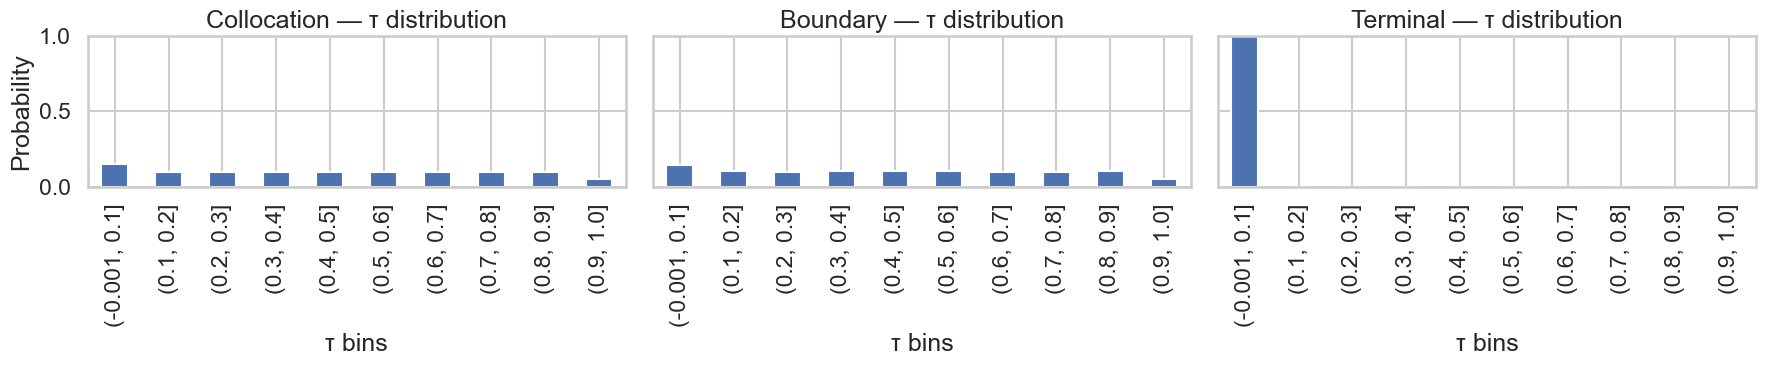

In [5]:
# τ distribution

tau_bins = np.linspace(0.0, 1.0, 11)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    tau_binned = pd.cut(df["tau"], bins=tau_bins, include_lowest=True)
    tau_dist = tau_binned.value_counts(normalize=True).sort_index()

    tau_dist.plot(kind="bar", ax=ax)
    ax.set_title(f"{name} — τ distribution")
    ax.set_xlabel("τ bins")
    ax.set_ylim(0, 1.0)

axes[0].set_ylabel("Probability")

plt.tight_layout()
plt.show()


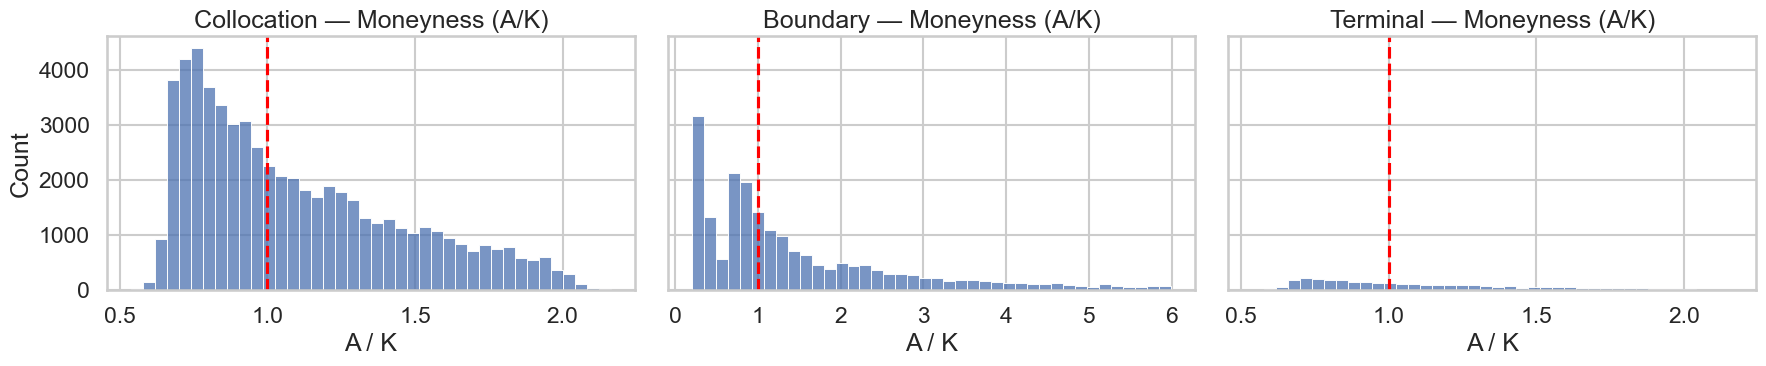

In [6]:
# MONEyness on Collocation
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    m = df["A"] / df["K"]

    sns.histplot(m, bins=40, ax=ax)
    ax.axvline(1.0, color="red", linestyle="--")
    ax.set_title(f"{name} — Moneyness (A/K)")
    ax.set_xlabel("A / K")

plt.tight_layout()
plt.show()



In [7]:
# MONEyness SPLIT (ITM / ATM / OTM)
print("MONEyness SPLIT (ITM / ATM / OTM)")

for name, df in datasets.items():
    m = df["A"] / df["K"]

    itm = (m > 1.05).mean()
    atm = ((m >= 0.95) & (m <= 1.05)).mean()
    otm = (m < 0.95).mean()

    print(f"\n{name}")
    print(f"  ITM  : {itm:6.2%}")
    print(f"  ATM  : {atm:6.2%}")
    print(f"  OTM  : {otm:6.2%}")


MONEyness SPLIT (ITM / ATM / OTM)

Collocation
  ITM  : 45.30%
  ATM  :  9.63%
  OTM  : 45.07%

Boundary
  ITM  : 47.80%
  ATM  :  4.76%
  OTM  : 47.44%

Terminal
  ITM  : 45.07%
  ATM  : 10.13%
  OTM  : 44.80%


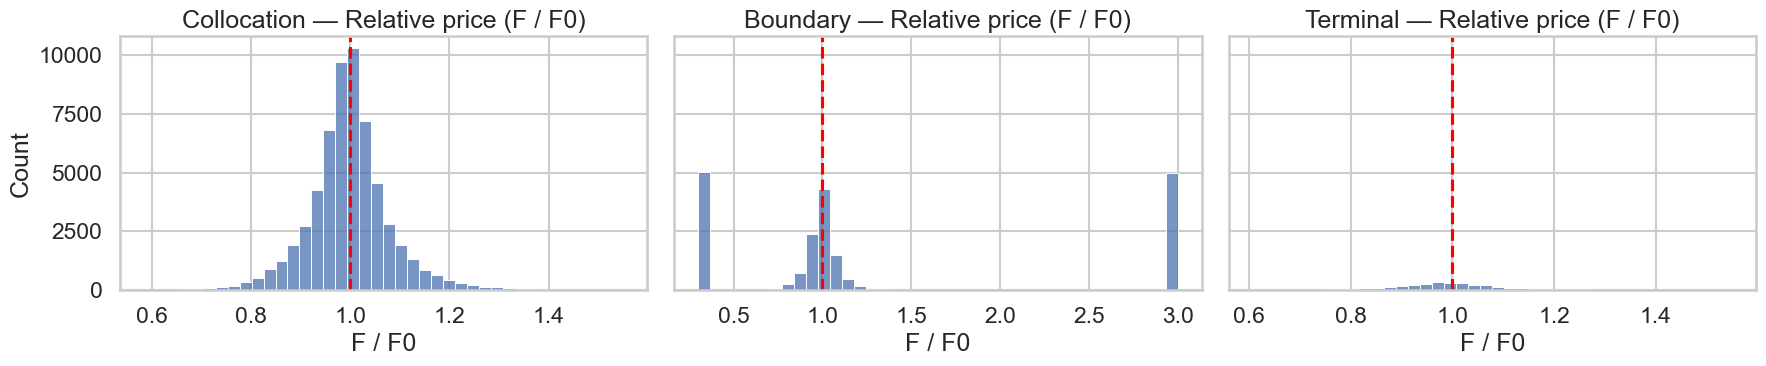

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    if "F0_ref" in df.columns:
        rel_price = df["F"] / df["F0_ref"]

        sns.histplot(rel_price, bins=40, ax=ax)
        ax.axvline(1.0, color="red", linestyle="--")

        ax.set_title(f"{name} — Relative price (F / F0)")
        ax.set_xlabel("F / F0")

plt.tight_layout()
plt.show()


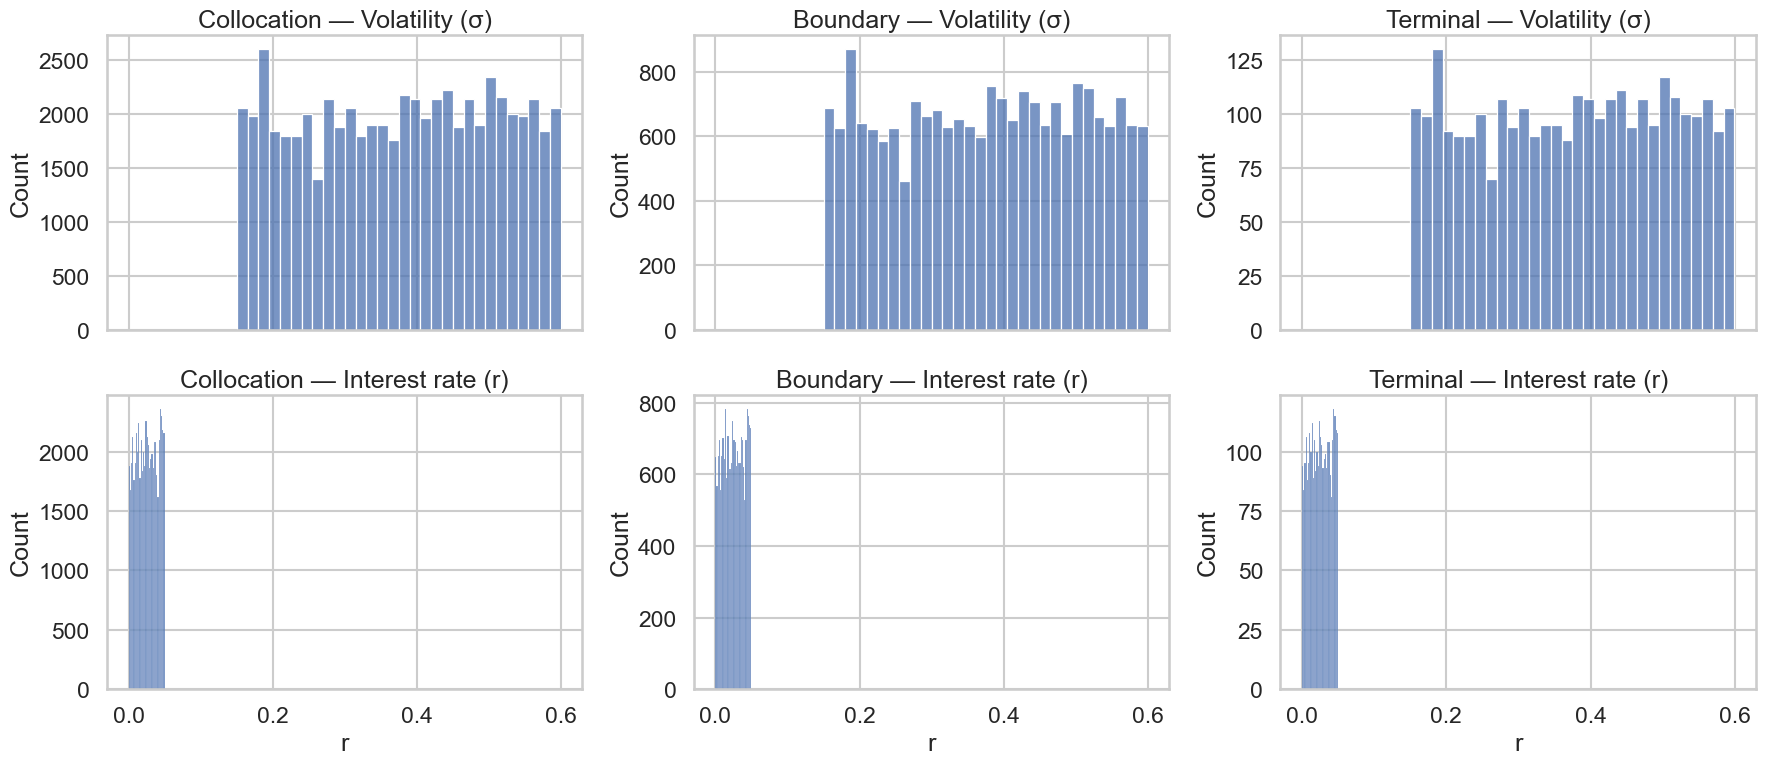

PARAMETER SPREAD (STD)

Collocation
  sigma std : 0.1305
  r std     : 0.0145

Boundary
  sigma std : 0.1300
  r std     : 0.0145

Terminal
  sigma std : 0.1305
  r std     : 0.0145


In [9]:
# PARAMETER SPREAD (STD)
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex="col")

for col_idx, (name, df) in enumerate(datasets.items()):
    sns.histplot(df["sigma"], bins=30, ax=axes[0, col_idx])
    axes[0, col_idx].set_title(f"{name} — Volatility (σ)")

    sns.histplot(df["r"], bins=30, ax=axes[1, col_idx])
    axes[1, col_idx].set_title(f"{name} — Interest rate (r)")

plt.tight_layout()
plt.show()


print("PARAMETER SPREAD (STD)")
for name, df in datasets.items():
    print(f"\n{name}")
    print(f"  sigma std : {df['sigma'].std():.4f}")
    print(f"  r std     : {df['r'].std():.4f}")


In [10]:
# COLLOCATION vs BOUNDARY COMPARISON
print("COLLOCATION vs BOUNDARY COMPARISON")

for col in ["tau", "F", "A"]:
    print(f"\nVariable: {col}")
    print(f"  Collocation mean/std : "
          f"{df_coll[col].mean():.4f} / {df_coll[col].std():.4f}")
    print(f"  Boundary    mean/std : "
          f"{df_bdry[col].mean():.4f} / {df_bdry[col].std():.4f}")


COLLOCATION vs BOUNDARY COMPARISON

Variable: tau
  Collocation mean/std : 0.4750 / 0.2883
  Boundary    mean/std : 0.4755 / 0.2875

Variable: F
  Collocation mean/std : 74.8503 / 21.0676
  Boundary    mean/std : 98.5162 / 82.2114

Variable: A
  Collocation mean/std : 74.8823 / 20.4070
  Boundary    mean/std : 98.5647 / 82.2925


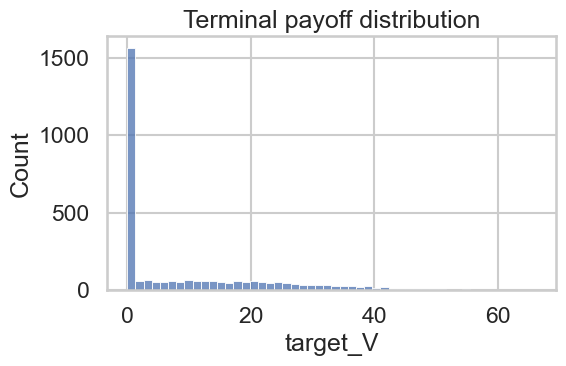

TERMINAL PAYOFF SPLIT
  Zero payoff     : 50.10%
  Positive payoff : 49.90%


In [11]:
# TERMINAL PAYOFF SPLIT
tv = df_term["target_V"]

plt.figure(figsize=(6, 4))
sns.histplot(tv, bins=50)
plt.title("Terminal payoff distribution")
plt.xlabel("target_V")
plt.tight_layout()
plt.show()

print("TERMINAL PAYOFF SPLIT")
print(f"  Zero payoff     : {(tv == 0).mean():6.2%}")
print(f"  Positive payoff : {(tv > 0).mean():6.2%}")


In [12]:
# FINAL DATASET BALANCE SCORE
score = 0

# τ coverage
if df_coll["tau"].std() > 0.25:
    score += 1

# Moneyness diversity
m = df_coll["A"] / df_coll["K"]
if (m > 1.05).mean() > 0.10 and (m < 0.95).mean() > 0.10:
    score += 1

# Parameter coverage
if df_coll["sigma"].std() > 0.10:
    score += 1

# Terminal diversity
if (tv == 0).mean() > 0.10 and (tv > 0).mean() > 0.10:
    score += 1

print("FINAL DATASET BALANCE SCORE")
print(f"Balance score: {score} / 4")


FINAL DATASET BALANCE SCORE
Balance score: 4 / 4


In [ ]:
metrics = evaluate_pinn_vs_mc(df_val, tau=0.999)
print("\nFinal metrics:", metrics)

# MODEL TRAINING

Start PINN Training...
[   1] total=1.152429  PDE=0.001171  term=0.045943  bnd=1.059371
[ 200] total=0.053690  PDE=0.005689  term=0.013910  bnd=0.020181
[ 400] total=0.009059  PDE=0.001020  term=0.001460  bnd=0.005119
[ 600] total=0.006308  PDE=0.000778  term=0.001236  bnd=0.003058
[ 800] total=0.003774  PDE=0.000428  term=0.000908  bnd=0.001530
[1000] total=0.003642  PDE=0.000467  term=0.001009  bnd=0.001158
[1200] total=0.002343  PDE=0.000290  term=0.000693  bnd=0.000667
[1400] total=0.002251  PDE=0.000292  term=0.000749  bnd=0.000462
[1600] total=0.002398  PDE=0.000408  term=0.000785  bnd=0.000420
[1800] total=0.001838  PDE=0.000243  term=0.000641  bnd=0.000313
[2000] total=0.001719  PDE=0.000215  term=0.000623  bnd=0.000257
[2200] total=0.001601  PDE=0.000199  term=0.000579  bnd=0.000243
[2400] total=0.001731  PDE=0.000172  term=0.000640  bnd=0.000278
[2600] total=0.001522  PDE=0.000261  term=0.000519  bnd=0.000223
[2800] total=0.001349  PDE=0.000224  term=0.000459  bnd=0.000207
[3

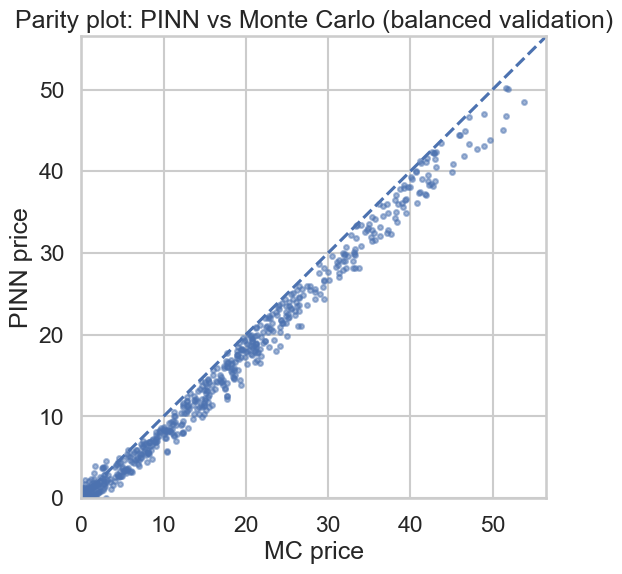

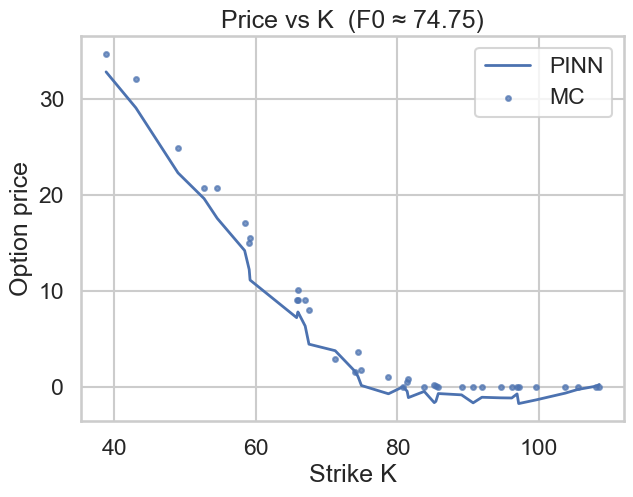


Metriche finali: {'MAE': 1.5306003093719482, 'RMSE': 1.9773892569608826, 'R2': 0.9776391983032227}


In [15]:
from evaluation import evaluate_pinn_vs_mc
# Normalizzazione
dfc = normalize_df(df_coll)
dft = normalize_df(df_term)
dfb = normalize_df(df_bdry)

Xc_full = pack_inputs(dfc)
Xt_full = pack_inputs(dft)
Xb_full = pack_inputs(dfb)

yT = torch.tensor((df_term["target_V"].values / df_term["F0_ref"].values),
                  dtype=torch.float32, device=DEVICE).unsqueeze(1)
yB = torch.tensor((df_bdry["target_V"].values / df_bdry["F0_ref"].values),
                  dtype=torch.float32, device=DEVICE).unsqueeze(1)

model = MLP().to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
mse = nn.MSELoss()

print("Start PINN Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()

    Xc, _ = minibatch(Xc_full, BATCH_C)
    Rc = pde_residual(model, Xc)
    loss_phys = torch.mean(Rc**2)

    Xt, it = minibatch(Xt_full, BATCH_T)
    pred_T = model(Xt)
    loss_term = mse(pred_T, yT[it])

    Xb, ib = minibatch(Xb_full, BATCH_B)
    pred_B = model(Xb)
    loss_bound = mse(pred_B, yB[ib])

    loss = ALPHA * loss_phys + BETA * loss_term + GAMMA * loss_bound

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    opt.step()
    scheduler.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"[{epoch:4d}] total={loss.item():.6f}  "
              f"PDE={loss_phys.item():.6f}  term={loss_term.item():.6f}  bnd={loss_bound.item():.6f}")


# MODEL EVALUATION


VAL – MAE=1.5306  RMSE=1.9774  R²=0.9776


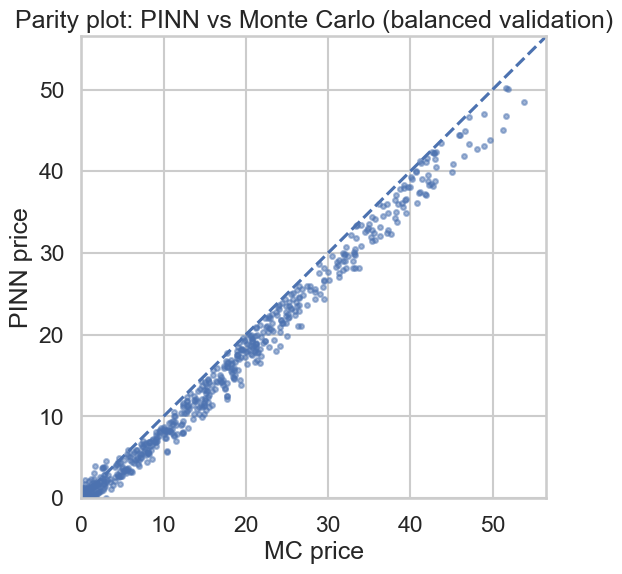

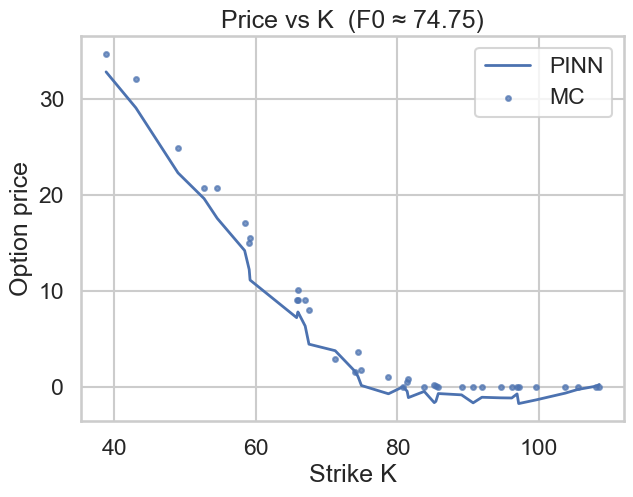


Metriche finali: {'MAE': 1.5306003093719482, 'RMSE': 1.9773892569608826, 'R2': 0.9776391983032227}


In [16]:
# Evaluation

def price_asian_pinn(F0, K, r, sigma, T_years, tau=0.999, A0=None):
    if A0 is None:
        A0 = F0
    x = torch.tensor([[tau, F0/F0, A0/F0, K/F0, r, sigma, T_years]],
                     dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        Vn = model(x).item()
    return Vn * F0

def pinn_price_batch(df, tau=0.999):
    model.eval()
    with torch.no_grad():
        F0 = df["F0"].values.astype(np.float32)
        K  = df["K"].values.astype(np.float32)
        r  = df["r"].values.astype(np.float32)
        s  = df["sigma"].values.astype(np.float32)
        T  = df["T_years"].values.astype(np.float32)
        A0 = F0.copy()

        X = np.stack([
            np.full_like(F0, tau, dtype=np.float32),
            F0 / F0,
            A0 / F0,
            K  / F0,
            r, s, T
        ], axis=1)
        X = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        Vn = model(X).cpu().numpy().reshape(-1)
        V  = Vn * F0
        return V

def evaluate_pinn_vs_mc(df_val, tau=0.999, sample_for_curve=300):
    price_pinn = pinn_price_batch(df_val, tau=tau)
    price_mc   = df_val["price_mc"].values.astype(np.float32)

    mae  = mean_absolute_error(price_mc, price_pinn)
    mse  = mean_squared_error(price_mc, price_pinn)
    rmse = np.sqrt(mse)
    r2   = r2_score(price_mc, price_pinn)
    print(f"\nVAL – MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

    # Parity plot
    plt.figure(figsize=(6,6))
    plt.scatter(price_mc, price_pinn, s=12, alpha=0.5)
    lims = [0, max(price_mc.max(), price_pinn.max()) * 1.05]
    plt.plot(lims, lims, linestyle="--")
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("MC price")
    plt.ylabel("PINN price")
    plt.title("Parity plot: PINN vs Monte Carlo (balanced validation)")
    plt.grid(True)
    plt.show()

    # Curva prezzo vs K a F0 ~ costante
    f0_med = df_val["F0"].median()
    tol = max(0.5, 0.02 * f0_med)
    sub = df_val[df_val["F0"].between(f0_med - tol, f0_med + tol)].copy()
    if len(sub) > sample_for_curve:
        sub = sub.sample(sample_for_curve, random_state=42)
    sub = sub.sort_values("K")
    sub_pinn = pinn_price_batch(sub, tau=tau)

    plt.figure(figsize=(7,5))
    plt.plot(sub["K"].values, sub_pinn, label="PINN", linewidth=2)
    plt.scatter(sub["K"].values, sub["price_mc"].values, s=12, alpha=0.7, label="MC")
    plt.xlabel("Strike K")
    plt.ylabel("Option price")
    plt.title(f"Price vs K  (F0 ≈ {f0_med:.2f})")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {"MAE":mae, "RMSE":rmse, "R2":r2}

# 9) RUN VALUTAZIONE

metrics = evaluate_pinn_vs_mc(df_val, tau=0.999)
print("\nMetriche finali:", metrics)
